In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv('train.csv')

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df = data[['Survived', 'Age', 'Fare']]
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [4]:
print((df['Age'].isnull()).sum())

177


In [5]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

/tmp/ipykernel_148062/1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_148062/1698716155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

- near to normal distribution.

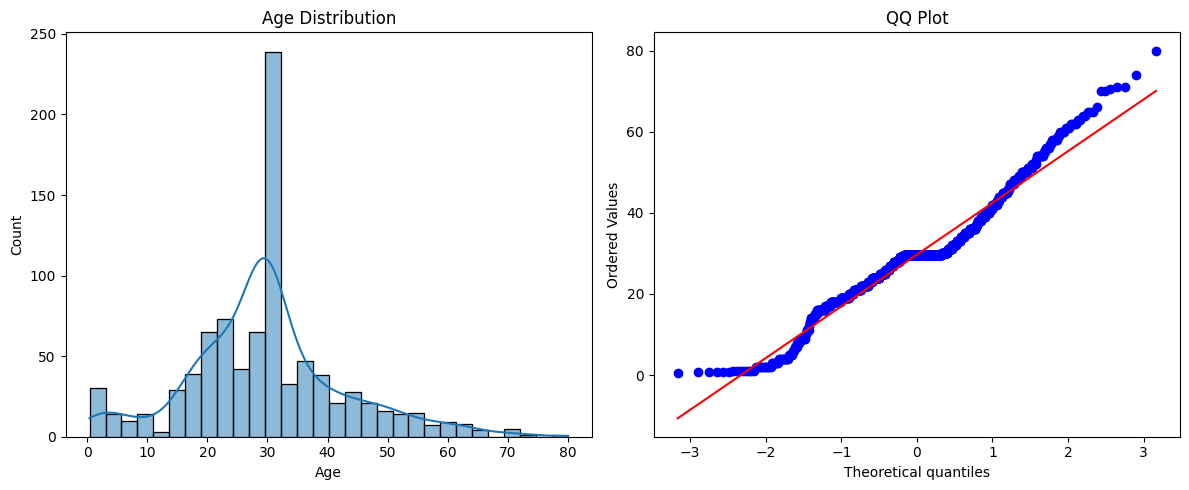

In [7]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Distribution Plot
sns.histplot(df['Age'], kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

# QQ Plot
stats.probplot(df['Age'], dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

- It is Highly right skwed as we already knew some of them had spet very high amount.
- Note: since it is right skwed, we can go for log transform.

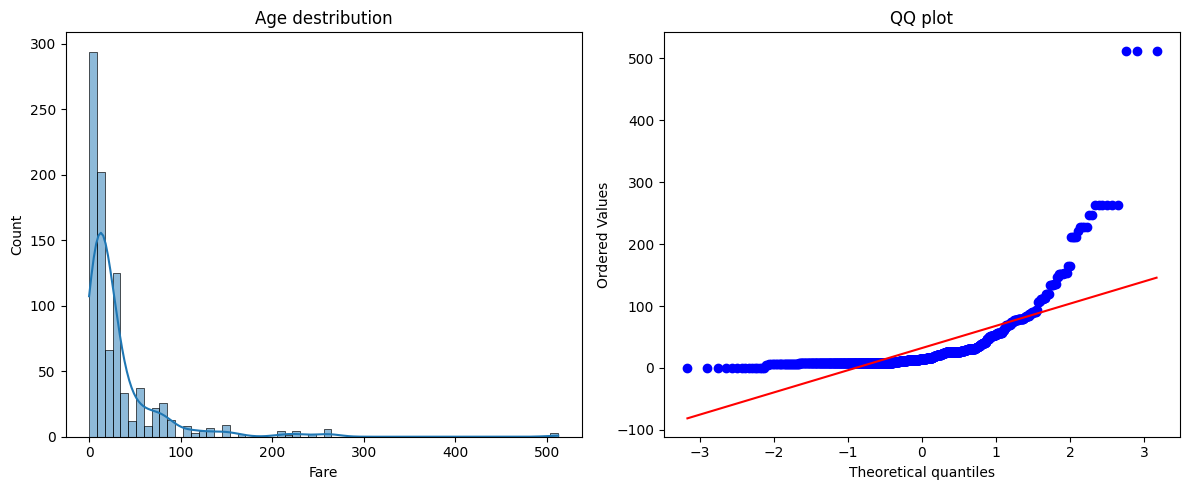

In [8]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.histplot(df['Fare'], kde=True, ax=axes[0])
axes[0].set_title('Age destribution')

stats.probplot(df['Fare'], dist='norm',  plot=axes[1])
axes[1].set_title('QQ plot')

plt.tight_layout()
plt.show()

In [9]:
x = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

l_clf = LogisticRegression()
d_clf = DecisionTreeClassifier()

l_clf.fit(x_train, y_train)
d_clf.fit(x_train, y_train)


l_pred = l_clf.predict(x_test)
d_pred = d_clf.predict(x_test)


print(f'Accuracy score of LogesticRegression: {accuracy_score(y_test, l_pred)}')
print(f'Accuracy score of DecisionTreeClassifier: {accuracy_score(y_test, d_pred,)}')

Accuracy score of LogesticRegression: 0.6480446927374302
Accuracy score of DecisionTreeClassifier: 0.6759776536312849


In [18]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

trf = FunctionTransformer(np.log1p)

tarin_transformed =trf.fit_transform(x_train)
test_transformed = trf.fit_transform(x_test)

trf_l_clf = LogisticRegression()
trf_d_clf = DecisionTreeClassifier()

trf_l_clf.fit(tarin_transformed, y_train)
trf_d_clf.fit(tarin_transformed, y_train)

trf_l_pred = trf_l_clf.predict(test_transformed)
trf_d_pred = trf_d_clf.predict(test_transformed)


print(f'Accuracy score of log transformed LR: {accuracy_score(y_test, trf_l_pred )}')
print(f'Accuracy score of log transformed DTC: {accuracy_score(y_test, trf_d_pred )}')

Accuracy score of log transformed LR: 0.6815642458100558
Accuracy score of log transformed DTC: 0.6871508379888268


In [21]:
from sklearn.model_selection import cross_val_score

x_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR ', np.mean(cross_val_score(clf, x_transformed, y, scoring='accuracy', cv = 10 )))
print('DTC ', np.mean(cross_val_score(clf2, x_transformed, y, scoring='accuracy', cv = 10 )))

LR  0.678027465667915
DTC  0.6554806491885145


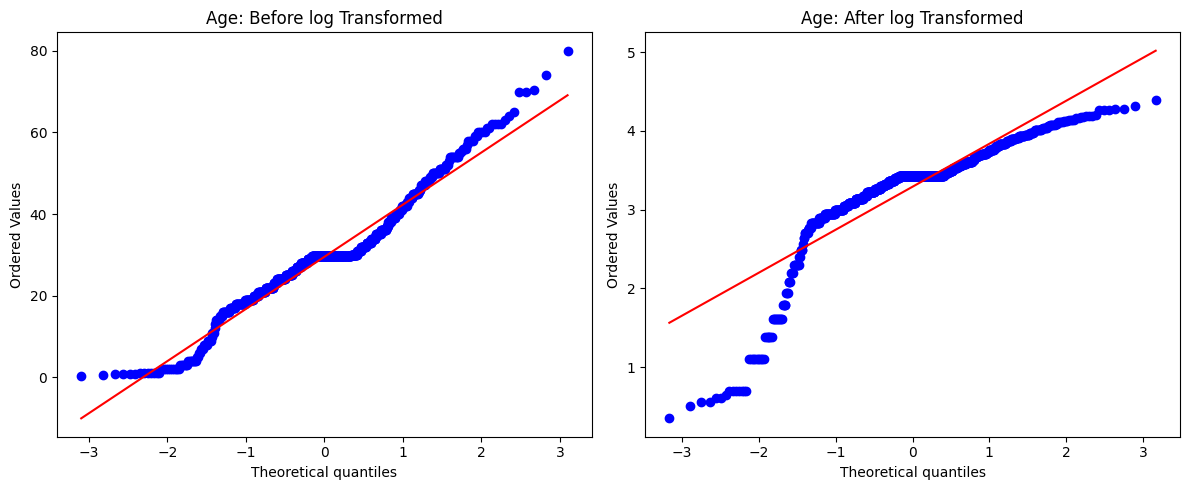

In [35]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

stats.probplot(x_train['Age'], dist='norm', plot=axes[0])
stats.probplot(x_transformed['Age'], dist='norm', plot=axes[1])

axes[0].set_title('Age: Before log Transformed')
axes[1].set_title('Age: After log Transformed')

plt.tight_layout()
plt.show()

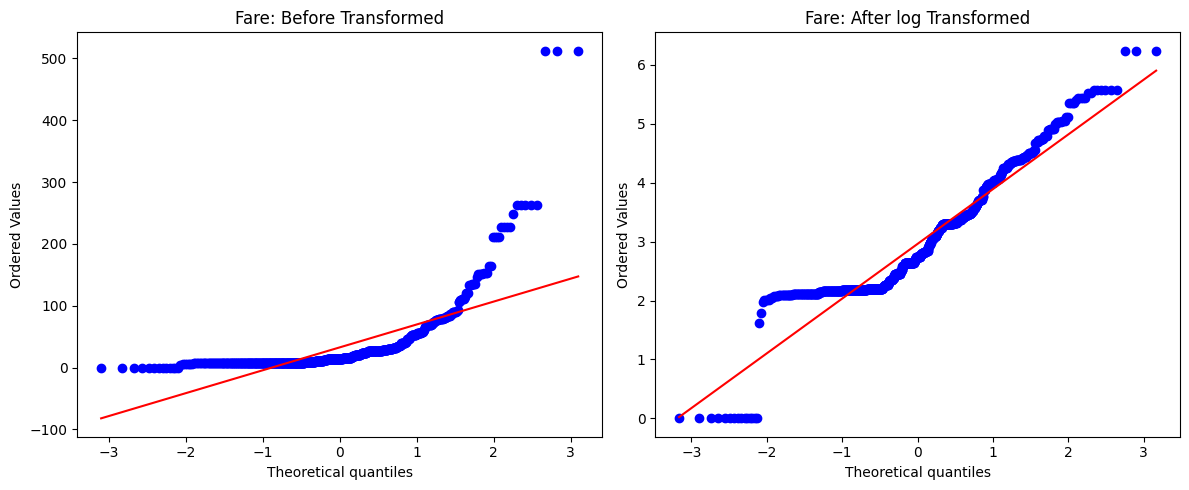

In [33]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

stats.probplot(x_train['Fare'], dist='norm', plot=axes[0])
stats.probplot(x_transformed['Fare'], dist='norm', plot=axes[1])

axes[0].set_title('Fare: Before Transformed')
axes[1].set_title('Fare: After log Transformed')

plt.tight_layout()
plt.show()

In [42]:
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')

x_trans_train = trf2.fit_transform(x_train)
x_trans_test = trf2.fit_transform(x_test)

clf_f = LogisticRegression()
clf_f2 = DecisionTreeClassifier()

clf_f.fit(x_trans_train, y_train)
clf_f2.fit(x_trans_train, y_train)


y_pred_f = clf_f.predict(x_trans_test)
y_pred_f2 = clf_f2.predict(x_trans_test)

print(f'Accuracy for LR: {accuracy_score(y_test, y_pred_f)}')
print(f'Accuracy for DTC: {accuracy_score(y_test, y_pred_f2)}')

Accuracy for LR: 0.6703910614525139
Accuracy for DTC: 0.6703910614525139


In [44]:
x_transformed2 = trf2.fit_transform(x)

clf_fp = LogisticRegression()
clf_fp2 = DecisionTreeClassifier()

print('LR: ', np.mean(cross_val_score(clf_fp, x_transformed2, y, scoring='accuracy', cv=10)))
print('DTC: ', np.mean(cross_val_score(clf_fp2, x_transformed2, y, scoring='accuracy', cv=10)))

LR:  0.6712609238451936
DTC:  0.6577278401997502


In [62]:
def apply_transform(func):
    
    X = df.iloc[:,1:]
    Y = df.iloc[:,0]
    
    trf = ColumnTransformer(
        [
            ('func', FunctionTransformer(func), ['Fare'])
        ],
        remainder='passthrough'
    )
    
    
    X_trans = trf.fit_transform(X)
    
    modl = LogisticRegression()
    
    print(f'Accuracy: {np.mean(cross_val_score(modl, X_trans, Y, scoring='accuracy', cv=10))}')
    
    fig, axes = plt.subplots(1,2, figsize=(12,5))
    
    stats.probplot(X['Fare'], dist='norm', plot=axes[0])
    axes[0].set_title('Before Transformation')
    
    stats.probplot(X_trans[:, 0], dist='norm', plot=axes[1])
    axes[0].set_title('After Transformation')
    
    plt.tight_layout()
    plt.show()

Accuracy: 0.6712609238451936


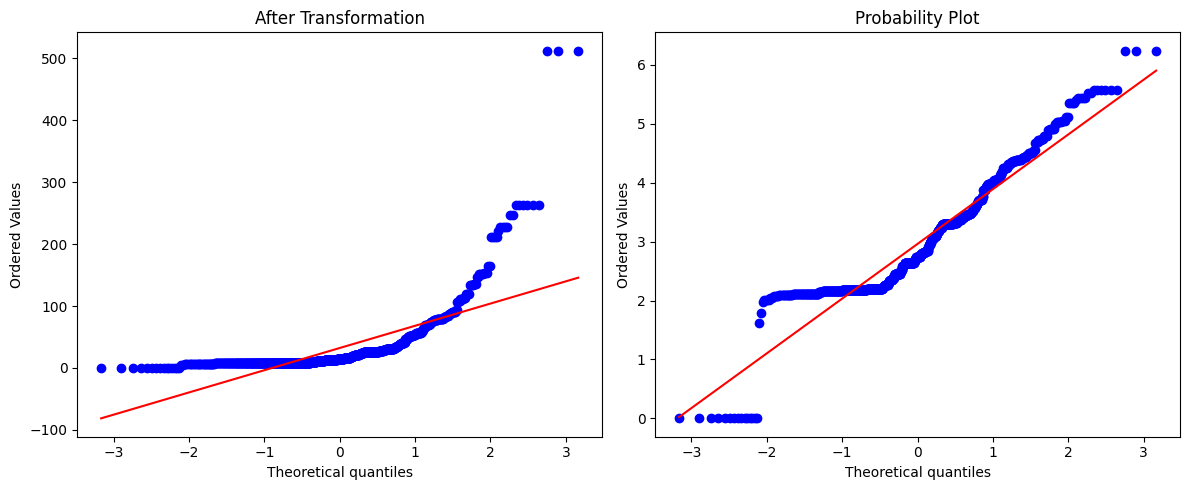

In [63]:
apply_transform(np.log1p)